In [31]:
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\daily_business_sales.csv"
)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)

(1885, 22)


In [32]:
# Prophet requires ds and y columns
prophet_df = df[
    ["date", "sales"]
].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

In [33]:
# Use last 30 days for testing
train_df = prophet_df.iloc[:-30]

test_df = prophet_df.iloc[-30:]

print(train_df.shape)
print(test_df.shape)

(1855, 2)
(30, 2)


In [34]:
from prophet import Prophet
# Forecast future sales

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_df)

22:56:32 - cmdstanpy - INFO - Chain [1] start processing
22:56:32 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(future)

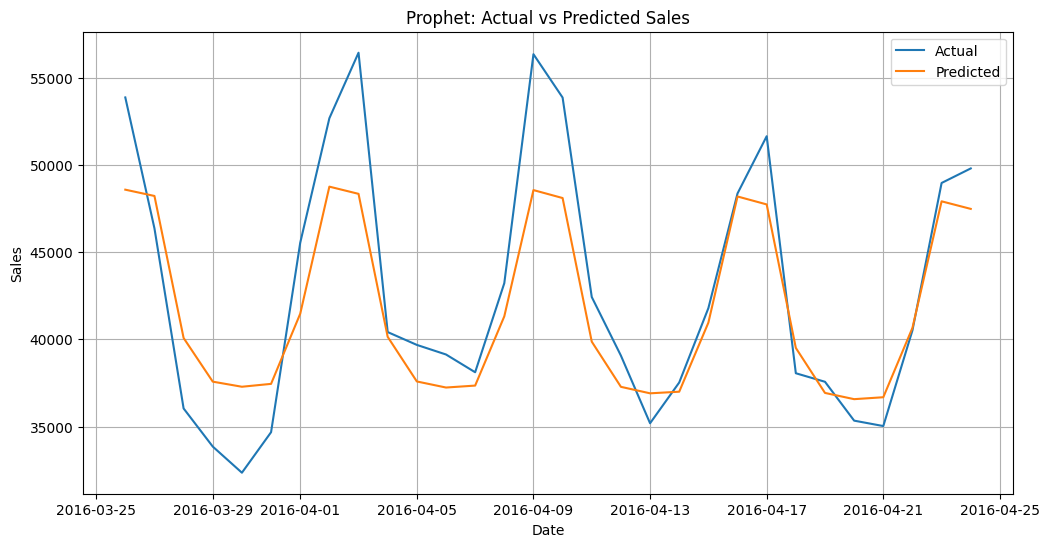

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from sklearn.metrics import mean_absolute_percentage_error

preds = forecast["yhat"].tail(30)

actuals = test_df["y"].values

# Compare actual and predicted sales

comparison_df = pd.DataFrame({

    "Date": test_df["ds"],

    "Actual": actuals,

    "Predicted": preds.values
})

comparison_df.head()


plt.figure(figsize=(12,6))

plt.plot(
    comparison_df["Date"],
    comparison_df["Actual"],
    label="Actual"
)

plt.plot(
    comparison_df["Date"],
    comparison_df["Predicted"],
    label="Predicted"
)

plt.title(
    "Prophet: Actual vs Predicted Sales"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [37]:
mae = mean_absolute_error(
    actuals,
    preds
)

rmse = mean_squared_error(
    actuals,
    preds
) ** 0.5


mape = mean_absolute_percentage_error(
    actuals,
    preds
) * 100


print("MAE :", mae)
print("RMSE:", rmse)
print(f"MAPE: {mape:.2f}%")

MAE : 2637.5326274738704
RMSE: 3361.5140789466327
MAPE: 5.98%


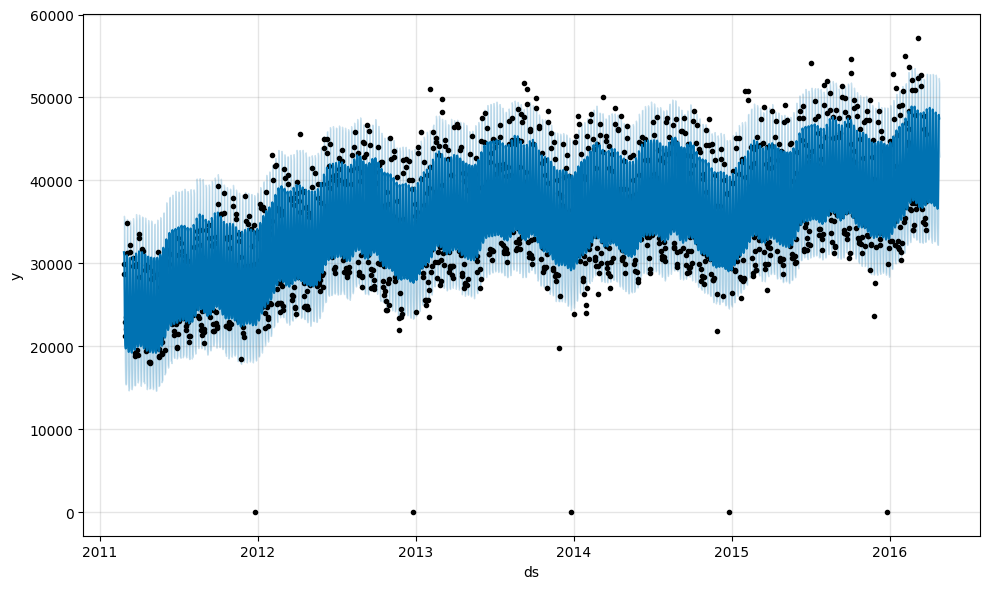

In [38]:
fig = model.plot(forecast)

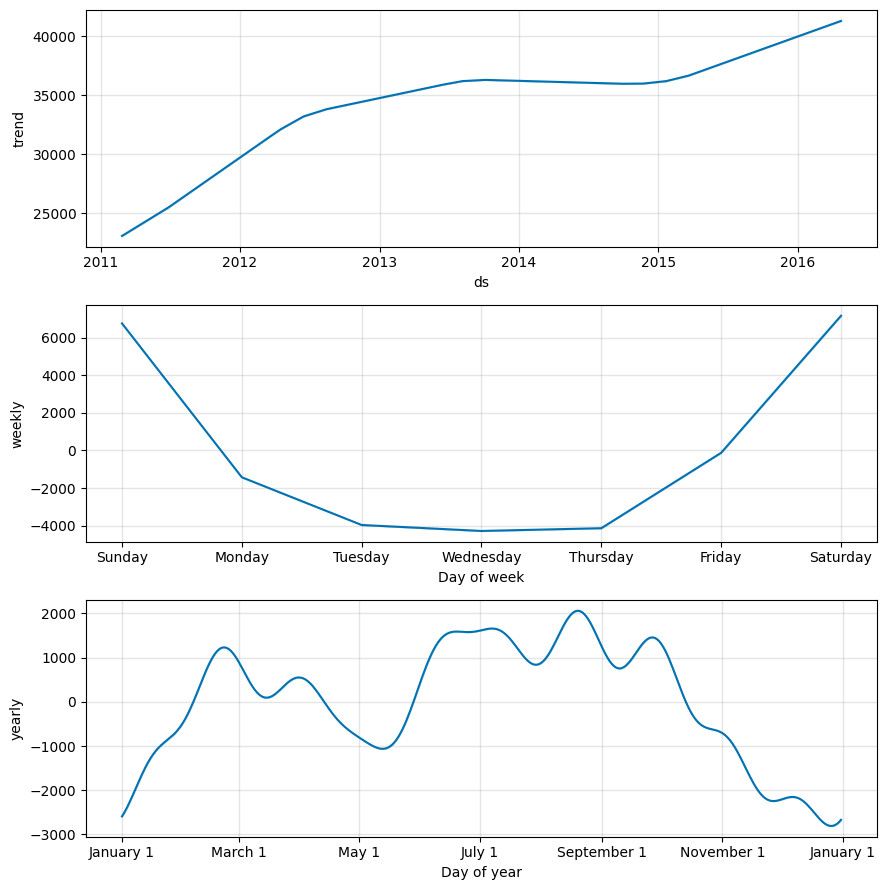

In [39]:
fig2 = model.plot_components(forecast)

In [40]:
forecast.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\business_sales_forecast.csv",
    index=False
)

In [41]:
print(df["sales"].describe())

count     1885.000000
mean     34461.923607
std       7305.360876
min         11.000000
25%      29780.000000
50%      33792.000000
75%      38902.000000
max      57218.000000
Name: sales, dtype: float64
